# How the combinatorial code emerged, root to extant

`01`-`05` compare repertoires at named nodes. This notebook puts every node on one
axis and asks how the code fills in between the single gnathostome ancestor
(`node_1`) and the 433-receptor human repertoire — and in particular how the Class I
side, the Class II side, and the ligands both classes share arrive relative to one
another.

It follows the recipe in a collaborator's memo (`FOR_IORDANA_trajectory.md`, A.
Pittis, 2026-08-20), which was written to be checked rather than copied. It has been
checked. Two of its three acceptance tests reproduce here, one does not, and the
reason it does not is a real methodological fork rather than a bug — see
**The endpoint disagreement** below. Everything the memo flags in its own §4 is
carried through, and one further issue it does not raise is added in
**Standing is not cumulative**.

| section | question |
|---|---|
| The axis | why relative time, and what ultrametricising costs |
| The tree | the ultrametric tree itself, which is the x axis of everything after |
| The trajectory | receptors, odorants by detecting class, detector counts |
| Founder ligands | what happens to `node_1`'s 21 ligands |
| Controls | is the shape history, or composition, or arithmetic? |
| Sensitivity | hyper-broad rows, and the endpoint disagreement |

Same density fill as the rest of the folder, no experimental overlay anywhere —
which is exactly the point at issue in the endpoint disagreement.

In [1]:
import sys
sys.path.append("../../scripts")
sys.path.append("../../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import (mpl_times, raw_times, lineage_slice, class_clades,
                            trajectory, asr_tree, density_grid, save_fig, save_table,
                            CLASSES)
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
BOTH_COL = "#b08a3e"          # ligands seen by both classes
NULL_COL = "#c9c9c4"

RNG = np.random.default_rng(0)

tree, index = asr_tree()
binary, prob, fills, ancestral = density_grid()
clades = class_clades()
classes = pd.read_csv(CLASSES)
leaf_class = dict(zip(classes.leaf_id, classes.OR_class))
extant_I = [k for k, v in leaf_class.items() if v == "Class_I"]
extant_II = [k for k, v in leaf_class.items() if v == "Class_II"]

print(f"grid           {binary.shape[0]} rows x {binary.shape[1]} ligands")
print(f"ASR fill       cut {fills['asr'].cut:.4f}   density {fills['asr'].density:.4%}")
print(f"extant fill    cut {fills['extant'].cut:.4f}   density {fills['extant'].density:.4%}")
print(f"class split    node_2 -> {len(clades['Class_I'] & set(leaf_class))} tips, "
      f"node_3 -> {len(clades['Class_II'] & set(leaf_class))} tips")

grid           865 rows x 754 ligands
ASR fill       cut 0.8875   density 2.2623%
extant fill    cut 0.8947   density 2.7453%
class split    node_2 -> 62 tips, node_3 -> 371 tips


## The axis

Repertoire size cannot be the x axis. Using it requires choosing an order in which
receptors appear, and the tree does not supply one — a node with two descendant
clades says nothing about which side fills first. The memo measures how much that
choice matters (§4.1): across 200 random resolution orders on the same topology,
"Class I only" at twenty receptors spans [28, 238]. The span reproduces here at
[13, 267] — not the same interval, since a random resolution order is only defined
up to how ties are broken, but the same verdict, and a wider one. See **Controls**.

So the axis is time, and the tree has to be made ultrametric to provide it. All 433
tips are present-day human genes, so the tree *should* be ultrametric in time and
its non-ultrametricity is rate variation — ultrametricising is a correction, not an
assumption. `mpl_times` applies mean path length (Britton et al. 2002) on the
ingroup rooted at `node_1`; the hagfish tip only roots the tree and never enters.

Two diagnostics, both of which the memo asks for.

In [2]:
mpl = mpl_times()
raw = raw_times()

print(f"root age {mpl.root_age:.4f} substitutions/site")
print(f"{len(mpl.clamped)} of 432 internal nodes needed clamping; "
      f"worst violation {mpl.clamped.excess_frac_root_age.max():.4f} of root age")
save_table(mpl.clamped, "06_clamped_nodes")
mpl.clamped.head(8)

root age 2.5604 substitutions/site
20 of 432 internal nodes needed clamping; worst violation 0.0371 of root age


,node,parent,excess_frac_root_age,n_tips
0,node_100,node_77,0.037053,2
1,node_13,node_7,0.033883,29
2,node_61,node_46,0.021392,13
3,node_51,node_38,0.019787,2
4,node_81,node_62,0.016815,7
5,node_161,node_137,0.016178,3
6,node_382,node_345,0.011416,3
7,node_380,node_344,0.008986,17


The memo's first acceptance test is "only 16 of 432 internal nodes need clamping,
worst violation 3.7% of root age". The worst violation reproduces exactly (3.71%,
`node_100`). The count does not: 20 nodes violate monotonicity here, not 16. The
gap is an unstated tolerance — 16 falls out at a cut of roughly 0.0012 of root age,
and the four extra nodes are all below that. Nothing hinges on it, but the count is
the wrong diagnostic to publish, because it depends on a number nobody stated. The
worst violation and the distribution are reproducible; the count is not.

Class II / Class I median tip depth: raw 1.287 -> ultrametric 1.000


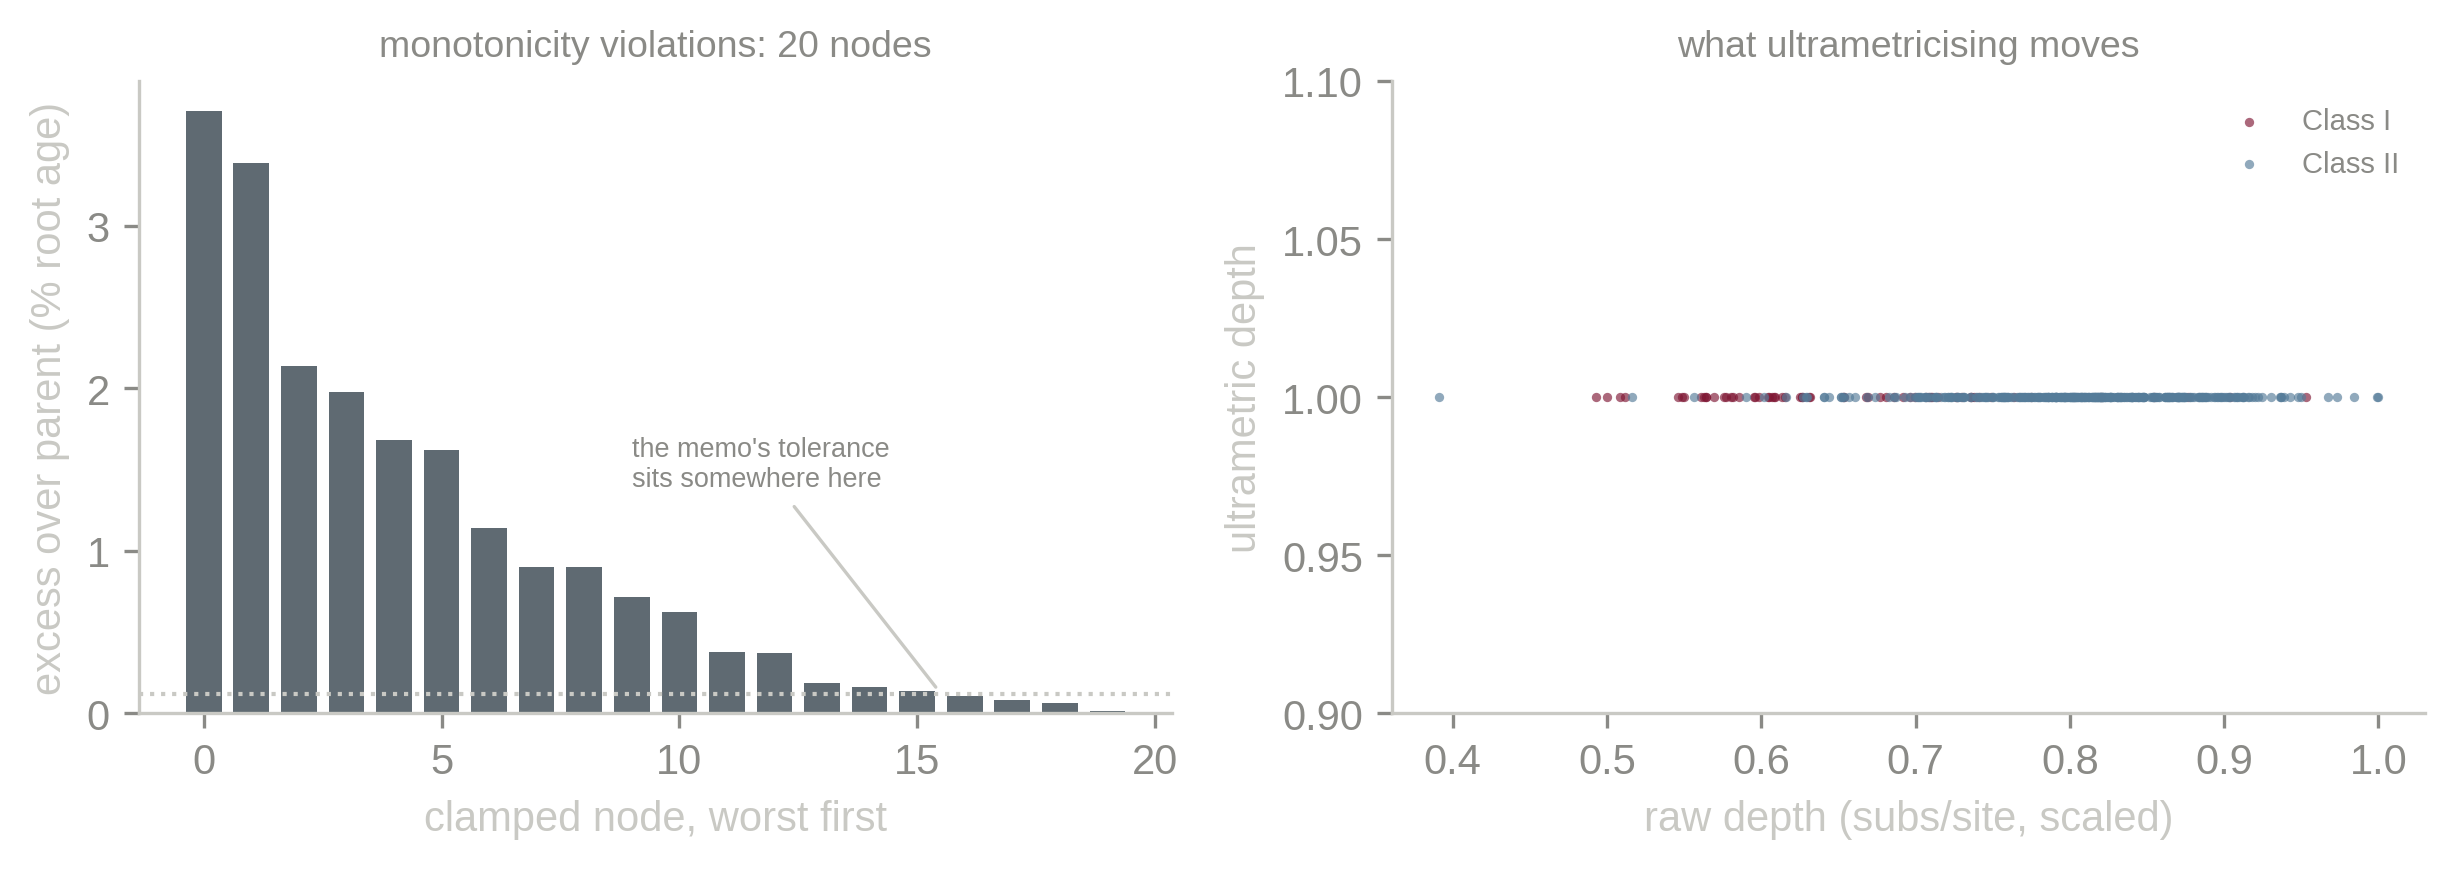

In [3]:
tips = [n.name for n in index["node_1"].leaves()]
depth_raw = {k: raw.t[k] for k in tips}
depth_mpl = {k: mpl.t[k] for k in tips}

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.1, FIGSIZE[1]))

ax = axes[0]
ax.bar(range(len(mpl.clamped)), mpl.clamped.excess_frac_root_age * 100,
       color=COMMON_COL, width=0.75)
ax.axhline(0.12, color=NULL_COL, ls=":", lw=1)
ax.set_xlabel("clamped node, worst first"); ax.set_ylabel("excess over parent (% root age)")
ax.set_title(f"monotonicity violations: {len(mpl.clamped)} nodes", fontsize=9)
ax.annotate("the memo's tolerance\nsits somewhere here", xy=(15.5, 0.12), xytext=(9, 1.4),
            fontsize=6.5, color="#8a8a86",
            arrowprops=dict(arrowstyle="-", color=NULL_COL, lw=0.8))

ax = axes[1]
for cls, col in [("Class_I", CLASS1_COL), ("Class_II", CLASS2_COL)]:
    members = [k for k in tips if leaf_class.get(k) == cls]
    ax.scatter([depth_raw[k] for k in members], [depth_mpl[k] for k in members],
               s=5, color=col, alpha=0.65, lw=0, label=cls.replace("_", " "))
ax.set_xlabel("raw depth (subs/site, scaled)"); ax.set_ylabel("ultrametric depth")
ax.set_ylim(0.9, 1.1); ax.legend(frameon=False, fontsize=7)
ax.set_title("what ultrametricising moves", fontsize=9)

ratio_raw = (np.median([depth_raw[k] for k in tips if leaf_class.get(k) == "Class_II"]) /
             np.median([depth_raw[k] for k in tips if leaf_class.get(k) == "Class_I"]))
ratio_mpl = (np.median([depth_mpl[k] for k in tips if leaf_class.get(k) == "Class_II"]) /
             np.median([depth_mpl[k] for k in tips if leaf_class.get(k) == "Class_I"]))
print(f"Class II / Class I median tip depth: raw {ratio_raw:.3f} -> ultrametric {ratio_mpl:.3f}")

plt.tight_layout(); save_fig(fig, "06_axis_diagnostics"); plt.show()

The memo's second acceptance test — Class II / Class I median tip depth going
**1.29x to 1.00x** — reproduces exactly (1.287 to 1.000). This is the test that
matters most, because it is the one that would catch a wrong MPL implementation,
and it passes. It is also the substance of the correction: Class II tips sit 29%
deeper in substitutions than Class I tips, and if that depth is read as time, Class
II looks old. Ultrametricising says it is fast, not old.

The memo is careful to say this is a bracket rather than a fix (§4.2) — MPL assumes
rate variation averages out, which is the assumption most under strain when the
rate difference is systematic and clade-level, which is precisely this case. Both
axes are therefore drawn together in **The trajectory**.

## The tree

The ultrametric tree is the x axis of every panel that follows, so it is worth
drawing once on its own. Tips are coloured by class; the `node_1` stem, which
belongs to neither class, is grey.

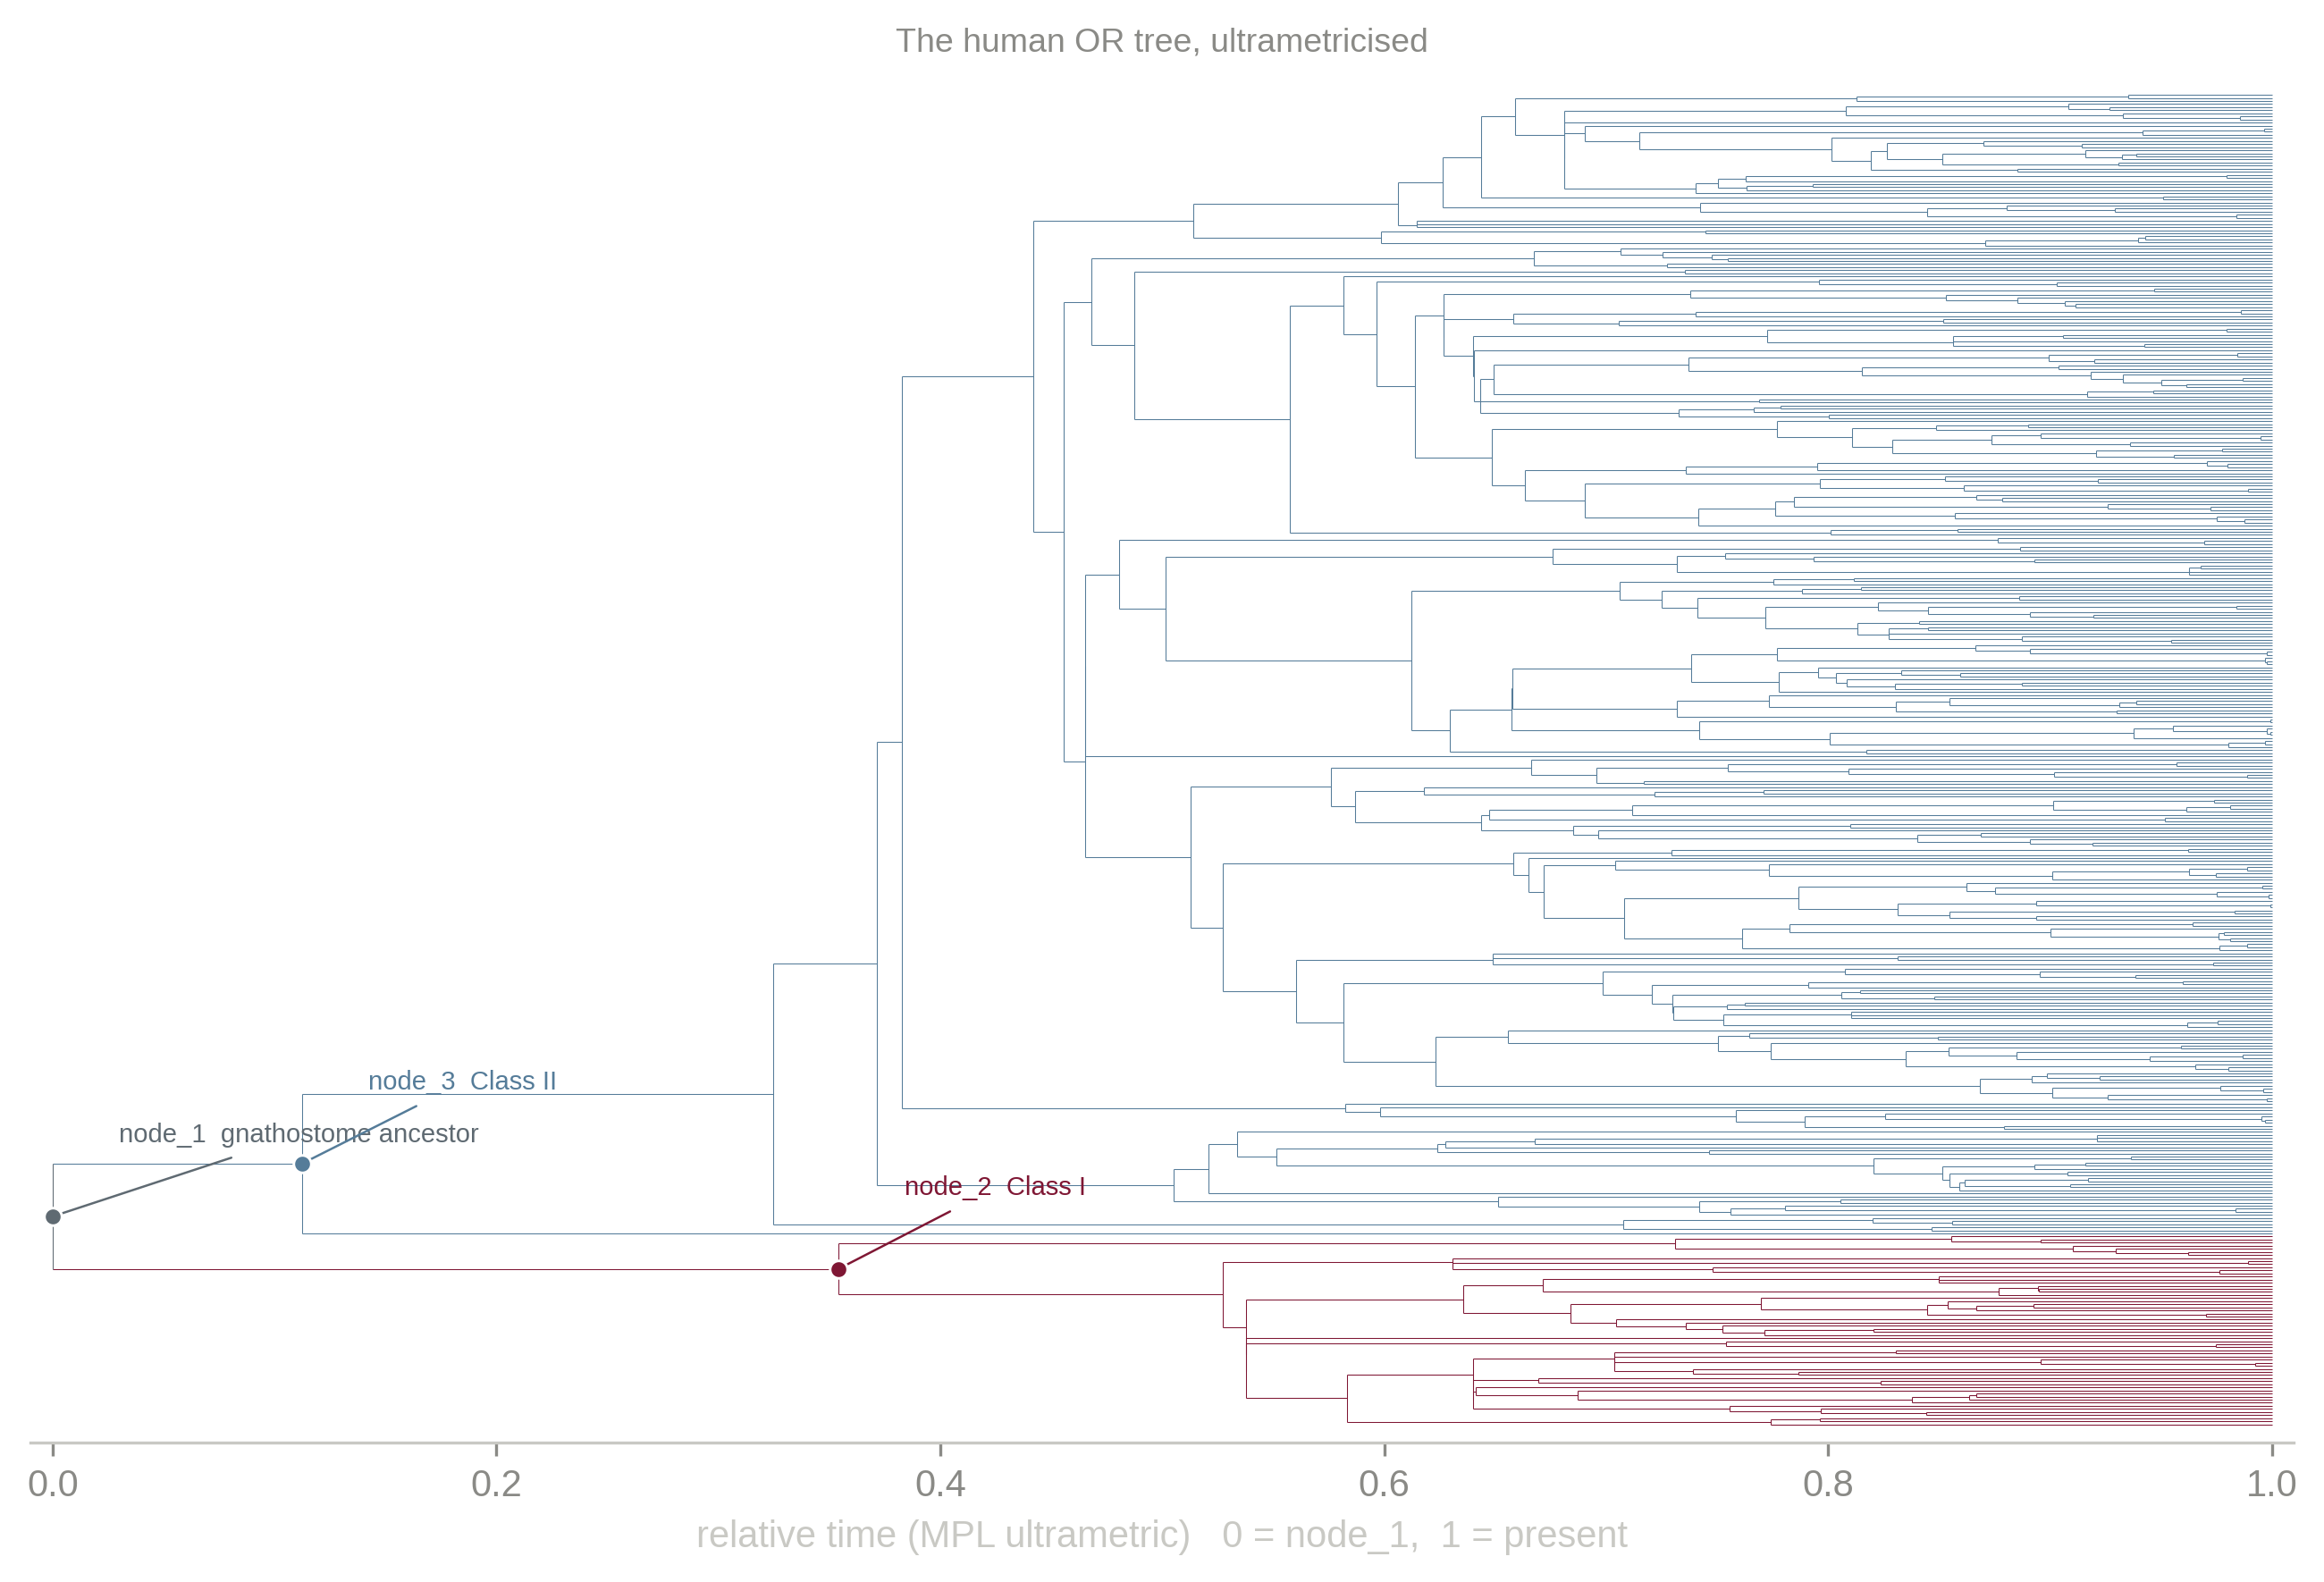

In [4]:
def layout(times, root="node_1"):
    # (x0, x1, y) per node, plus the y-span of each internal node's children
    r = index[root]
    y, order = {}, [n for n in r.leaves()]
    for i, leaf in enumerate(order):
        y[leaf.name] = float(i)
    for n in r.traverse("postorder"):
        if not n.is_leaf:
            y[n.name] = float(np.mean([y[c.name] for c in n.children]))
    seg, vert = {}, {}
    for n in r.traverse():
        x1 = times.t[n.name]
        x0 = 0.0 if n is r else times.t[n.up.name]
        seg[n.name] = (x0, x1, y[n.name])
        if not n.is_leaf:
            vert[n.name] = (x1, min(y[c.name] for c in n.children),
                            max(y[c.name] for c in n.children))
    return seg, vert, y


def draw_tree(ax, times, lw=0.18, root="node_1"):
    seg, vert, y = layout(times, root)
    for name, (x0, x1, yy) in seg.items():
        if name in clades["Class_I"]:
            col = CLASS1_COL
        elif name in clades["Class_II"]:
            col = CLASS2_COL
        else:
            col = COMMON_COL
        ax.plot([x0, x1], [yy, yy], color=col, lw=lw, solid_capstyle="butt")
    for name, (x, lo, hi) in vert.items():
        col = (CLASS1_COL if name in clades["Class_I"] else
               CLASS2_COL if name in clades["Class_II"] else COMMON_COL)
        ax.plot([x, x], [lo, hi], color=col, lw=lw, solid_capstyle="butt")
    ax.set_ylim(-6, len(y and [k for k in y if index[k].is_leaf]) + 6)
    ax.set_yticks([]); ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    return seg, y


fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1] * 2.0))
seg, ypos = draw_tree(ax, mpl, lw=0.25)
for name, label, col in [("node_1", "node_1  gnathostome ancestor", COMMON_COL),
                         ("node_2", "node_2  Class I", CLASS1_COL),
                         ("node_3", "node_3  Class II", CLASS2_COL)]:
    x, yy = mpl.t[name], ypos[name]
    ax.scatter([x], [yy], s=22, color=col, zorder=5, edgecolor="white", lw=0.7)
    ax.annotate(label, xy=(x, yy), xytext=(x + 0.03, yy + 24), fontsize=7, color=col,
                arrowprops=dict(arrowstyle="-", color=col, lw=0.6))
ax.set_xlabel("relative time (MPL ultrametric)   0 = node_1,  1 = present")
ax.set_xlim(-0.01, 1.01)
ax.set_title("The human OR tree, ultrametricised", fontsize=9)
plt.tight_layout(); save_fig(fig, "06_ultrametric_tree"); plt.show()

The 62-tip Class I clade and the 371-tip Class II clade are visible as the two
blocks, and the Class II radiation is visibly denser toward the present. That
density is the thing the trajectory quantifies.

## The trajectory

**The repertoire at time _t_ is the set of lineages crossing _t_.** A branch
leading to `v` occupies the interval `[t(parent(v)), t(v))`, so the lineage crossing
`t` on that branch is `v` — an internal node contributes its ASR row, a tip
contributes its extant row. No ordering is required, which is the whole point.

One wording note for anyone reimplementing from the memo: its rule is given as
"tip v : `t(v) <= t`". Under ultrametricity every tip has `t(v) = 1`, so read
literally no tip ever enters before `t = 1` and the rule is vacuous. The rule that
actually reproduces the memo's own receptor counts is the standard lineages-through-
time slice used here, tips included on the same interval rule. Its numbers are
right; the sentence describing them is not.

In [5]:
traj = trajectory(mpl)
traj_raw = trajectory(raw)
save_table(traj, "06_trajectory")
save_table(traj_raw, "06_trajectory_raw_axis")

checkpoints = [0.0, 0.25, 0.50, 0.75, 0.83, 0.90, 0.96, 1.0]
rows = [traj.iloc[(traj.t - q).abs().argmin()] for q in checkpoints]
view = pd.DataFrame(rows)[["t", "n_class_I", "n_class_II", "n_detected", "cum_detected",
                           "n_single", "n_combinatorial", "only_I", "both", "only_II"]]
print(view.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

     t  n_class_I  n_class_II  n_detected  cum_detected  n_single  n_combinatorial  only_I  both  only_II
     0          0           0          21            21        21                0       0     0        0
0.3246          1           3          40            47        31                9      18     3       19
0.5016          2          13          60            66        30               30      26     6       28
0.7505         26         113         535           536       103              432      21   237      277
0.8304         37         184         651           651        98              553      33   263      355
0.9004         54         251         657           657        88              569      32   318      307
0.9598         56         310         657           657        84              573      32   318      307
     1         62         371         668           671        50              618      15   342      311


Receptor counts reproduce the memo's table: 26 + 112 at *t* = 0.75, 54 + 251 at
0.90 (memo 54 + 254), 62 + 371 at 1.0. The odorant counts sit a few percent below
the memo's throughout, for the reason given in **The endpoint disagreement**.

Now the composite figure. The tree sits on top, and the three panels below share its
x axis, so a feature in a curve can be read straight up to the part of the tree that
produced it.

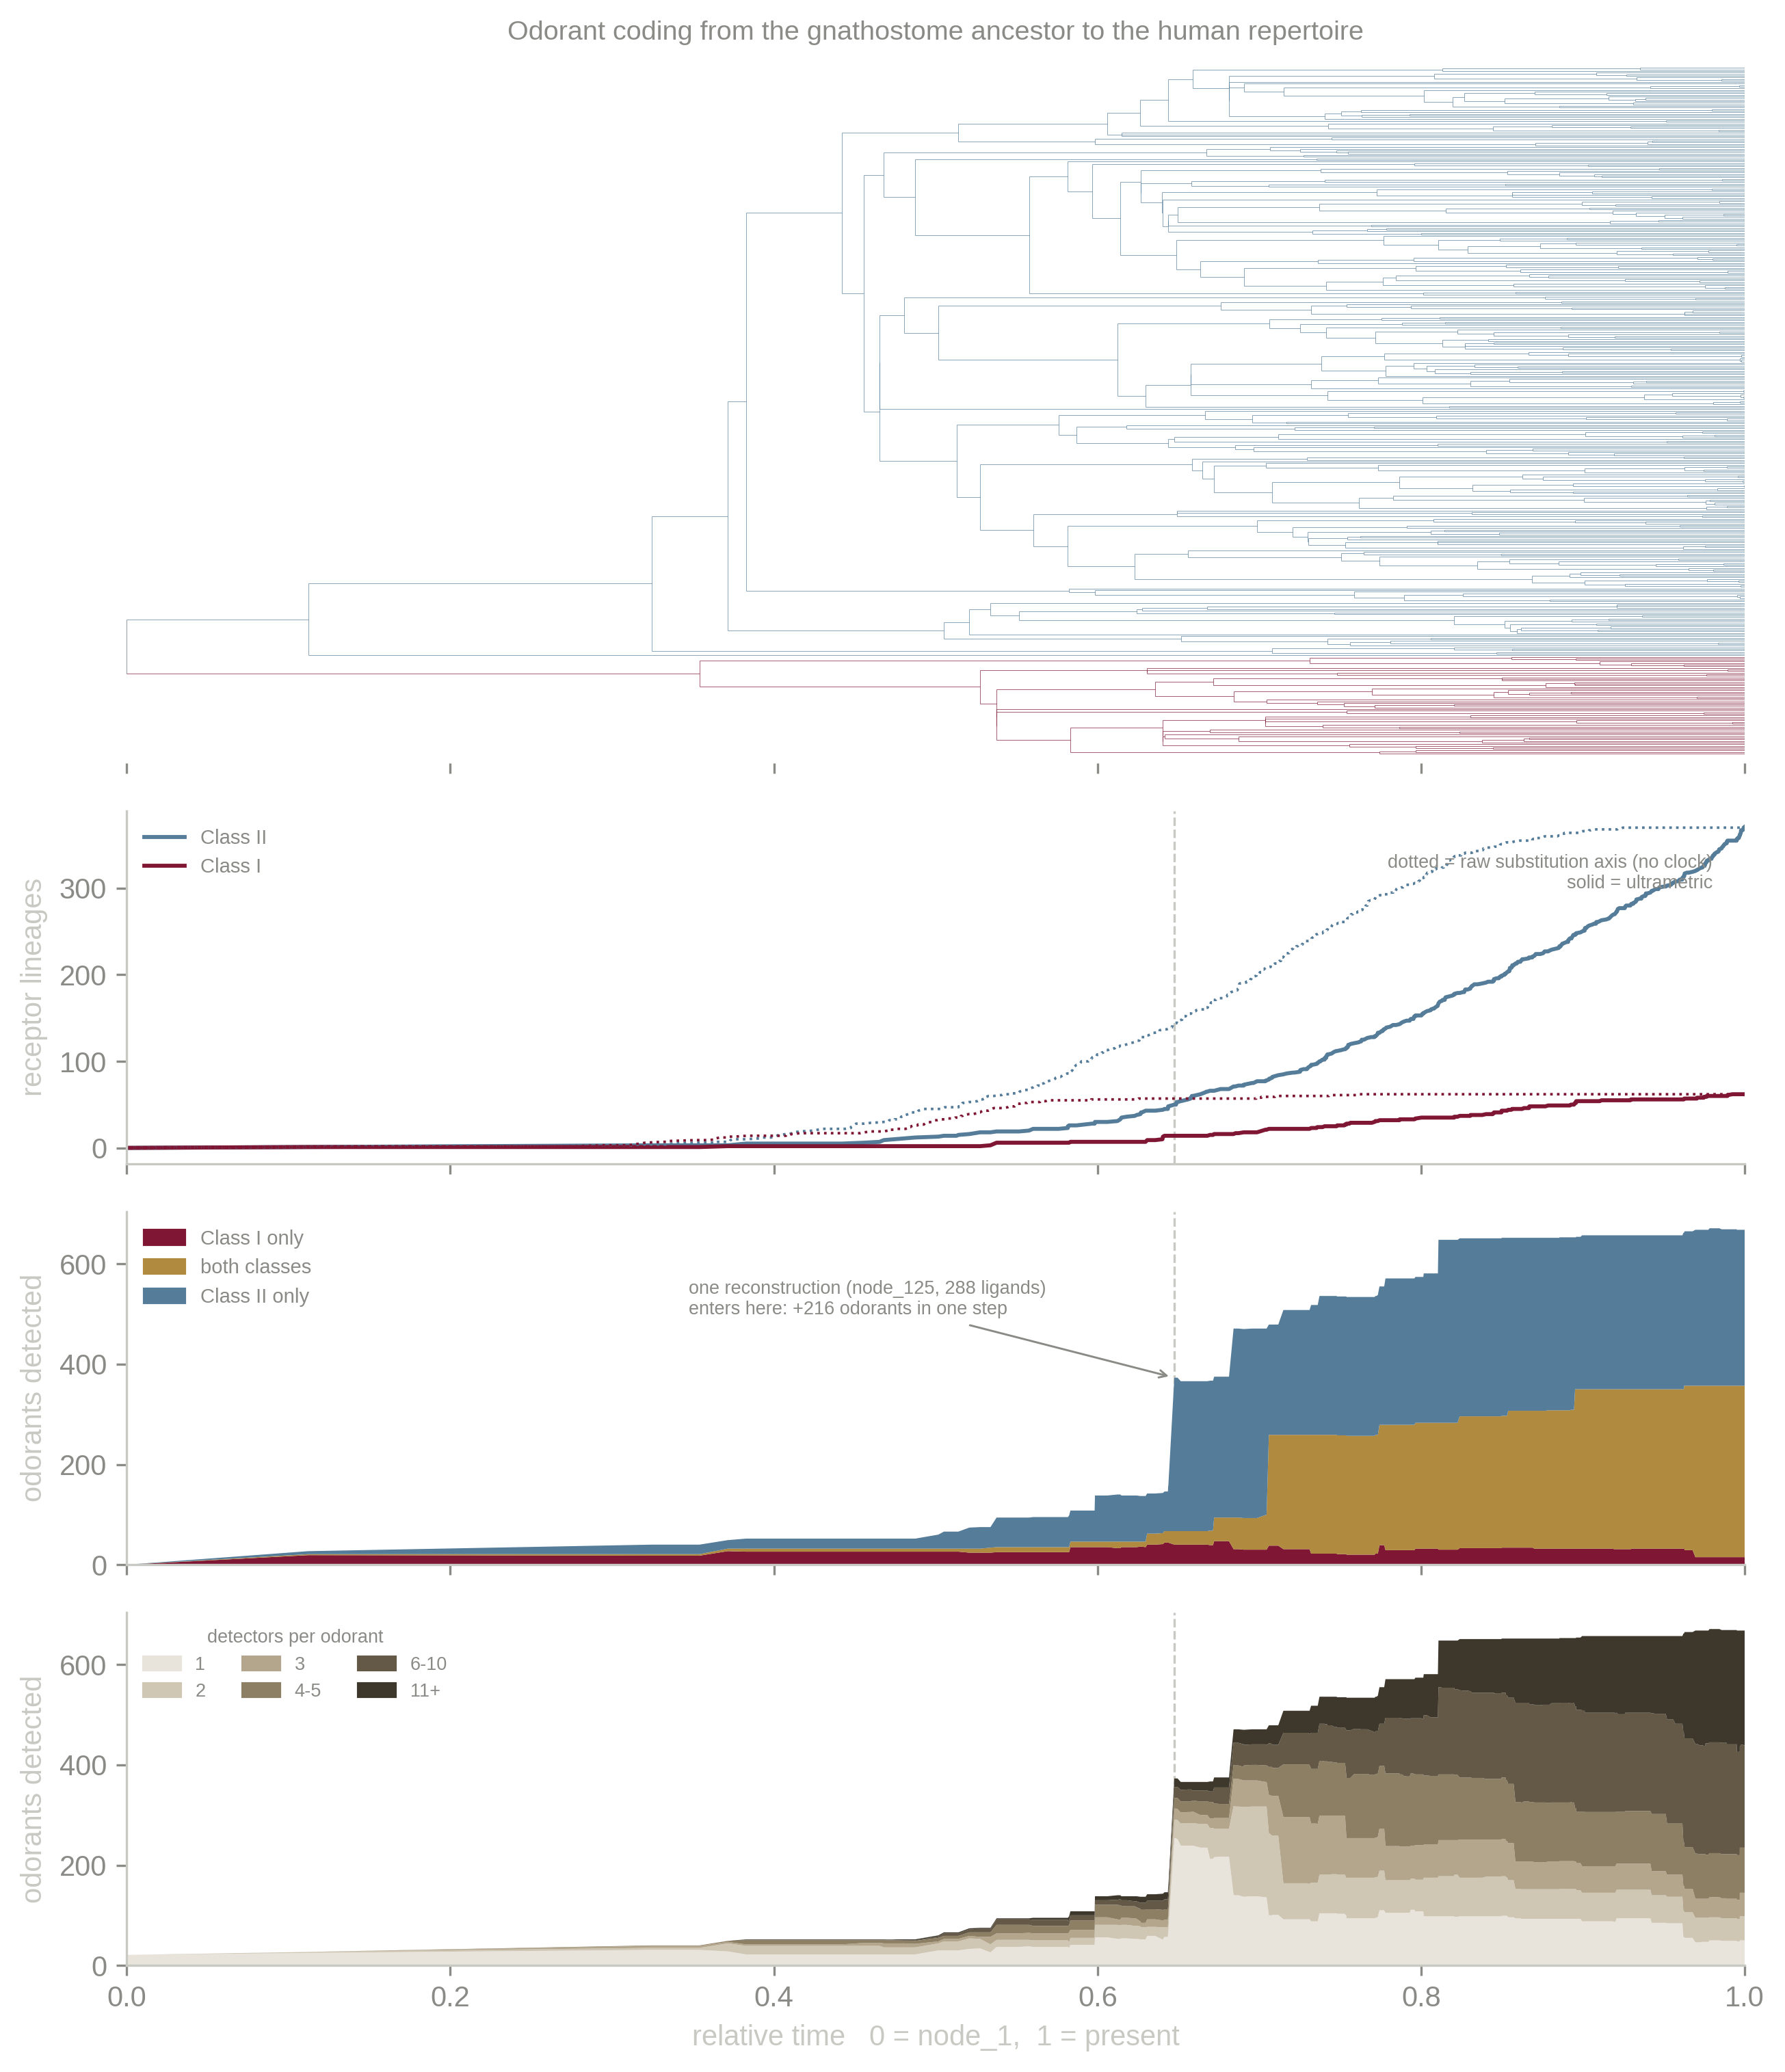

largest single step at t=0.6475: 157 -> 373 odorants


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1] * 3.4),
                         sharex=True, height_ratios=[2.0, 1.0, 1.0, 1.0])

draw_tree(axes[0], mpl, lw=0.16)
axes[0].set_title("Odorant coding from the gnathostome ancestor to the human repertoire",
                  fontsize=9.5)
axes[0].spines["bottom"].set_visible(False)

# the single step that dominates the figure: one very broad reconstruction
step_i = int(traj.n_detected.diff().abs().idxmax())
step_t = float(traj.t.iloc[step_i])

ax = axes[1]
ax.plot(traj.t, traj.n_class_II, color=CLASS2_COL, lw=1.4, label="Class II")
ax.plot(traj.t, traj.n_class_I, color=CLASS1_COL, lw=1.4, label="Class I")
ax.plot(traj_raw.t, traj_raw.n_class_II, color=CLASS2_COL, lw=0.9, ls=":")
ax.plot(traj_raw.t, traj_raw.n_class_I, color=CLASS1_COL, lw=0.9, ls=":")
ax.set_ylabel("receptor lineages")
ax.legend(frameon=False, fontsize=7, loc="upper left")
ax.annotate("dotted = raw substitution axis (no clock)\nsolid = ultrametric",
            xy=(0.98, 0.78), xycoords="axes fraction", fontsize=6.5, color="#8a8a86",
            ha="right")

ax = axes[2]
ax.stackplot(traj.t, traj.only_I, traj.both, traj.only_II,
             colors=[CLASS1_COL, BOTH_COL, CLASS2_COL], lw=0)
ax.set_ylabel("odorants detected")
ax.legend(handles=[Patch(color=CLASS1_COL, label="Class I only"),
                   Patch(color=BOTH_COL, label="both classes"),
                   Patch(color=CLASS2_COL, label="Class II only")],
          frameon=False, fontsize=7, loc="upper left")
ax.annotate("one reconstruction (node_125, 288 ligands)\nenters here: +216 odorants in one step",
            xy=(step_t, 373), xytext=(step_t - 0.30, 500), fontsize=6.5, color="#8a8a86",
            arrowprops=dict(arrowstyle="->", color="#8a8a86", lw=0.7))

ax = axes[3]
cols = ["det_1", "det_2", "det_3", "det_4_5", "det_6_10", "det_11plus"]
labels = ["1", "2", "3", "4-5", "6-10", "11+"]
shades = ["#e8e4dc", "#cfc6b4", "#b3a68c", "#8d7f64", "#645946", "#3d372c"]
ax.stackplot(traj.t, *[traj[c] for c in cols], colors=shades, lw=0)
ax.set_ylabel("odorants detected")
ax.set_xlabel("relative time   0 = node_1,  1 = present")
ax.legend(handles=[Patch(color=s, label=l) for s, l in zip(shades, labels)],
          frameon=False, fontsize=6.5, loc="upper left", ncol=3, title="detectors per odorant",
          title_fontsize=6.5)
ax.set_xlim(0, 1)

for a in axes[1:]:
    a.axvline(step_t, color=NULL_COL, ls="--", lw=0.8, zorder=0)

plt.tight_layout(); save_fig(fig, "06_trajectory"); plt.show()
print(f"largest single step at t={step_t:.4f}: "
      f"{int(traj.n_detected.iloc[step_i-1])} -> {int(traj.n_detected.iloc[step_i])} odorants")

The bottom panel is the memo's own suggestion (§5) and it is the right call: the
full detector-count distribution says everything the 1-versus-many split says, and
sidesteps the two problems in §4.4 at once. The "single detector" category is soft
— the memo shows the 61 singly-detected odorants sit a median 0.0136 above the cut
against 0.0846 for the combinatorial ones — so a binary split puts a hard line
through the softest part of the data. A distribution does not.

**The step at *t* = 0.65 is not an event.** The single most conspicuous feature of
this figure — the standing repertoire jumping from 157 to 373 odorants — is one
lineage entering the slice: `node_125`, a reconstruction called at 288 ligands
against a median of 6. The three steps after it are the same phenomenon. This is the
memo's §5 warning about hyper-broad rows, and it turns out not to be a footnote but
the dominant term in the figure's shape. Blanking rows above 100 ligands drops the
largest single step from 216 odorants to 56 and the endpoint from 668 to 371 — see
**Sensitivity**. Nothing in the class-level conclusions depends on it, but no
sentence should be written about *when* the code expanded without saying this first.

Reading the class panel: "both classes" grows throughout while "Class I only"
stays a thin band that thins further toward the present. The shared ligand pool is
therefore not an inherited ancestral condition — it is built late, over a Class I
repertoire already in place. That is the memo's §3 claim and it holds here. But see
**Controls**, because a large part of the shape is composition rather than history.

## Standing is not cumulative

One issue the memo does not raise. The slice is a **standing** repertoire: crossing
a node replaces one lineage by its two children, so the union of odorants the slice
detects can *fall* as *t* increases. It is not a growth curve, and "how the code
fills in" reads as though it were.

8 of 412 steps decrease the standing odorant count; largest single drop -7 odorants
standing at t=1: 668   cumulative union over the whole sweep: 671


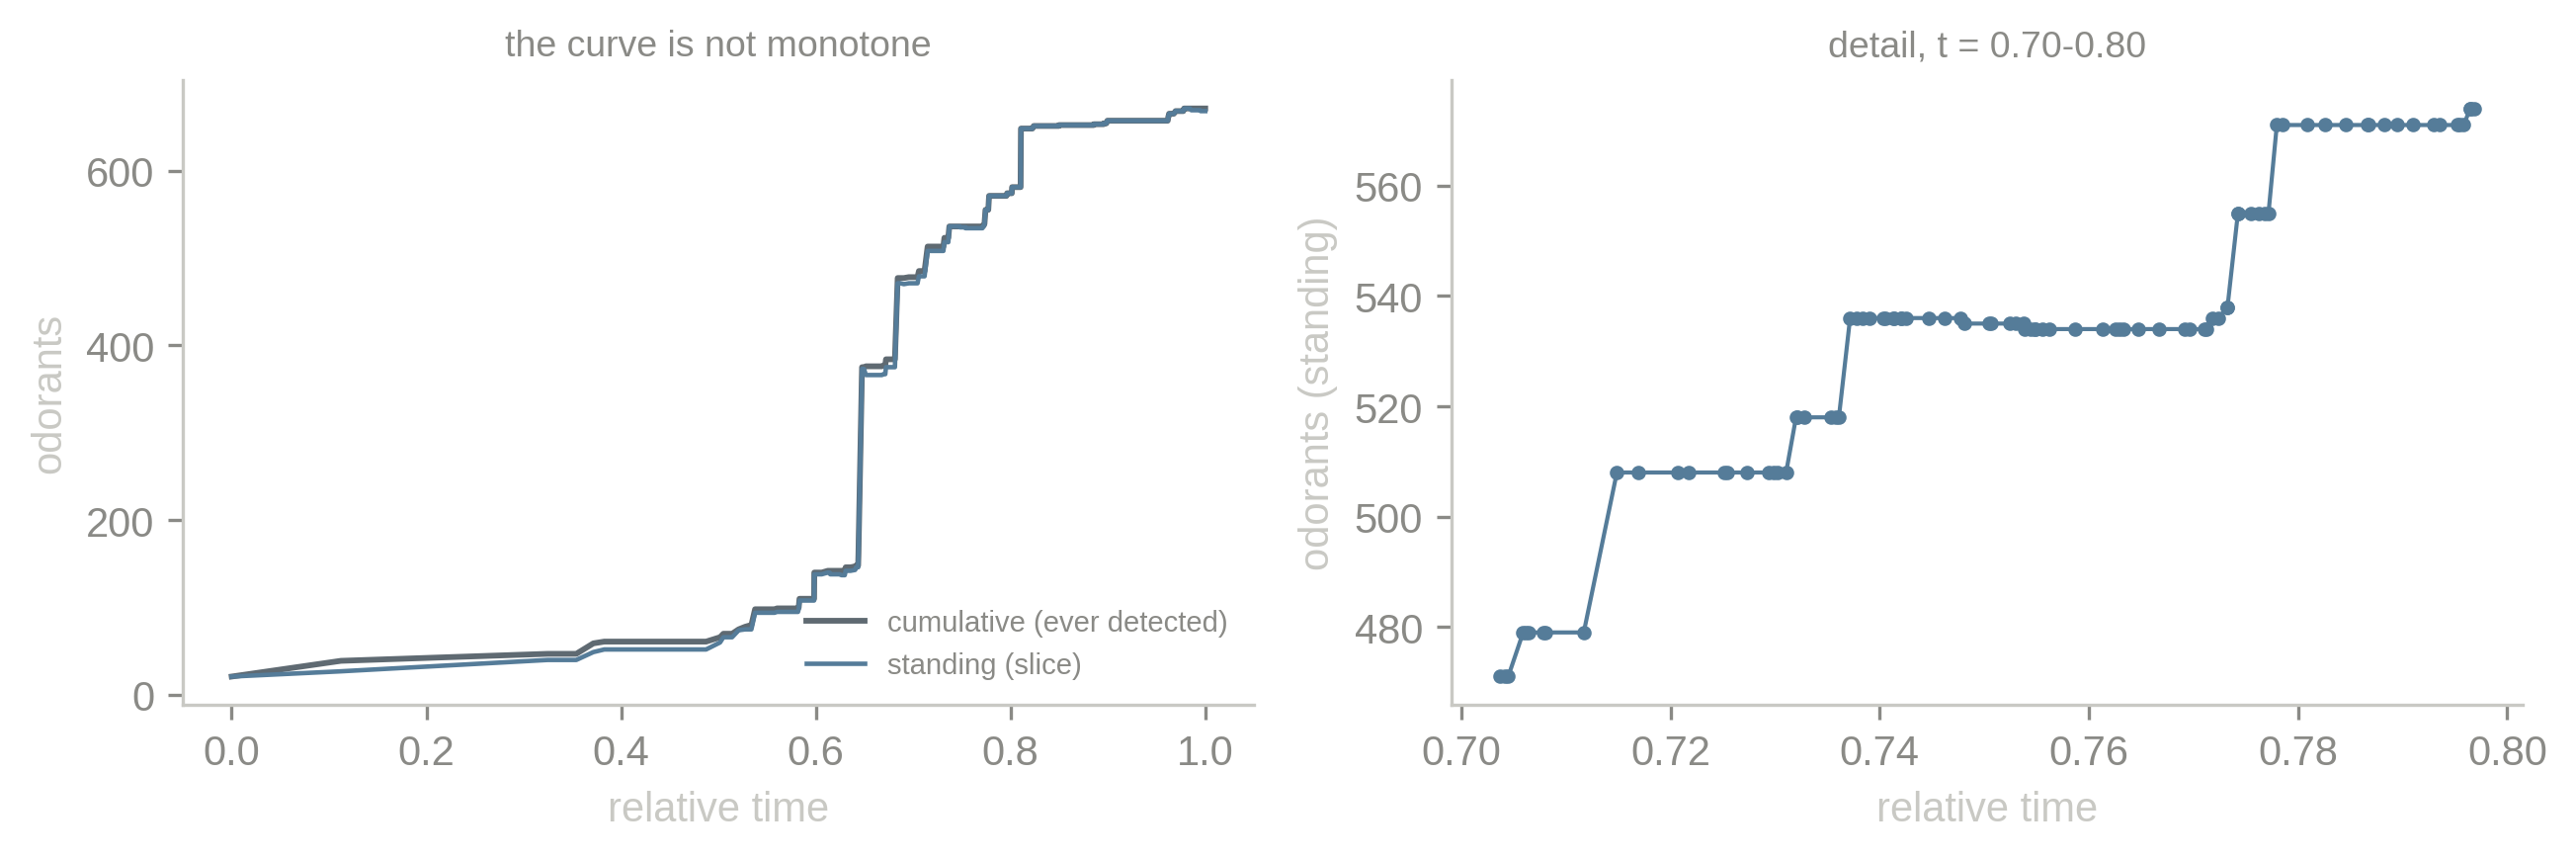

In [7]:
d = np.diff(traj.n_detected.values)
drops = int((d < 0).sum())
print(f"{drops} of {len(d)} steps decrease the standing odorant count; "
      f"largest single drop {int(d.min())} odorants")
print(f"standing at t=1: {int(traj.n_detected.iloc[-1])}   "
      f"cumulative union over the whole sweep: {int(traj.cum_detected.iloc[-1])}")

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1]))

ax = axes[0]
ax.plot(traj.t, traj.cum_detected, color=COMMON_COL, lw=1.4, label="cumulative (ever detected)")
ax.plot(traj.t, traj.n_detected, color=CLASS2_COL, lw=1.1, label="standing (slice)")
ax.set_xlabel("relative time"); ax.set_ylabel("odorants")
ax.legend(frameon=False, fontsize=7, loc="lower right")
ax.set_title("the curve is not monotone", fontsize=9)

ax = axes[1]
window = (traj.t > 0.70) & (traj.t < 0.80)
ax.plot(traj.t[window], traj.n_detected[window], color=CLASS2_COL, lw=1.0, marker="o", ms=2.5)
ax.set_xlabel("relative time"); ax.set_ylabel("odorants (standing)")
ax.set_title("detail, t = 0.70-0.80", fontsize=9)

plt.tight_layout(); save_fig(fig, "06_standing_vs_cumulative"); plt.show()

This has a practical consequence for the memo's headline table, which reports
intermediate odorant counts as exact integers (549, 650, 660, 678). Those numbers
are not stable to a small shift in where the checkpoint falls, because a single
hyper-broad lineage entering or leaving the slice moves the count by tens. The
right presentation is the curve with its jitter visible — as above — not four
significant figures in a table.

Report the shape. The endpoints (`node_1` at 21 odorants, the extant repertoire at
668) are solid because they are not slices of anything; the intermediate values are
an estimator with real variance.

## Founder ligands

The memo tracks classes. It does not track what happened to the ancestor's own
repertoire, which is the more direct reading of "how the code evolved": of the 21
odorants `node_1` is reconstructed to bind, what becomes of them?

The answer to the obvious version of that question is degenerate — all 21 are still
detected at the present, by both classes, none lost. So the quantity worth plotting
is not *whether* they survive but *how many receptors pile onto them*.

node_1 binds 21 odorants


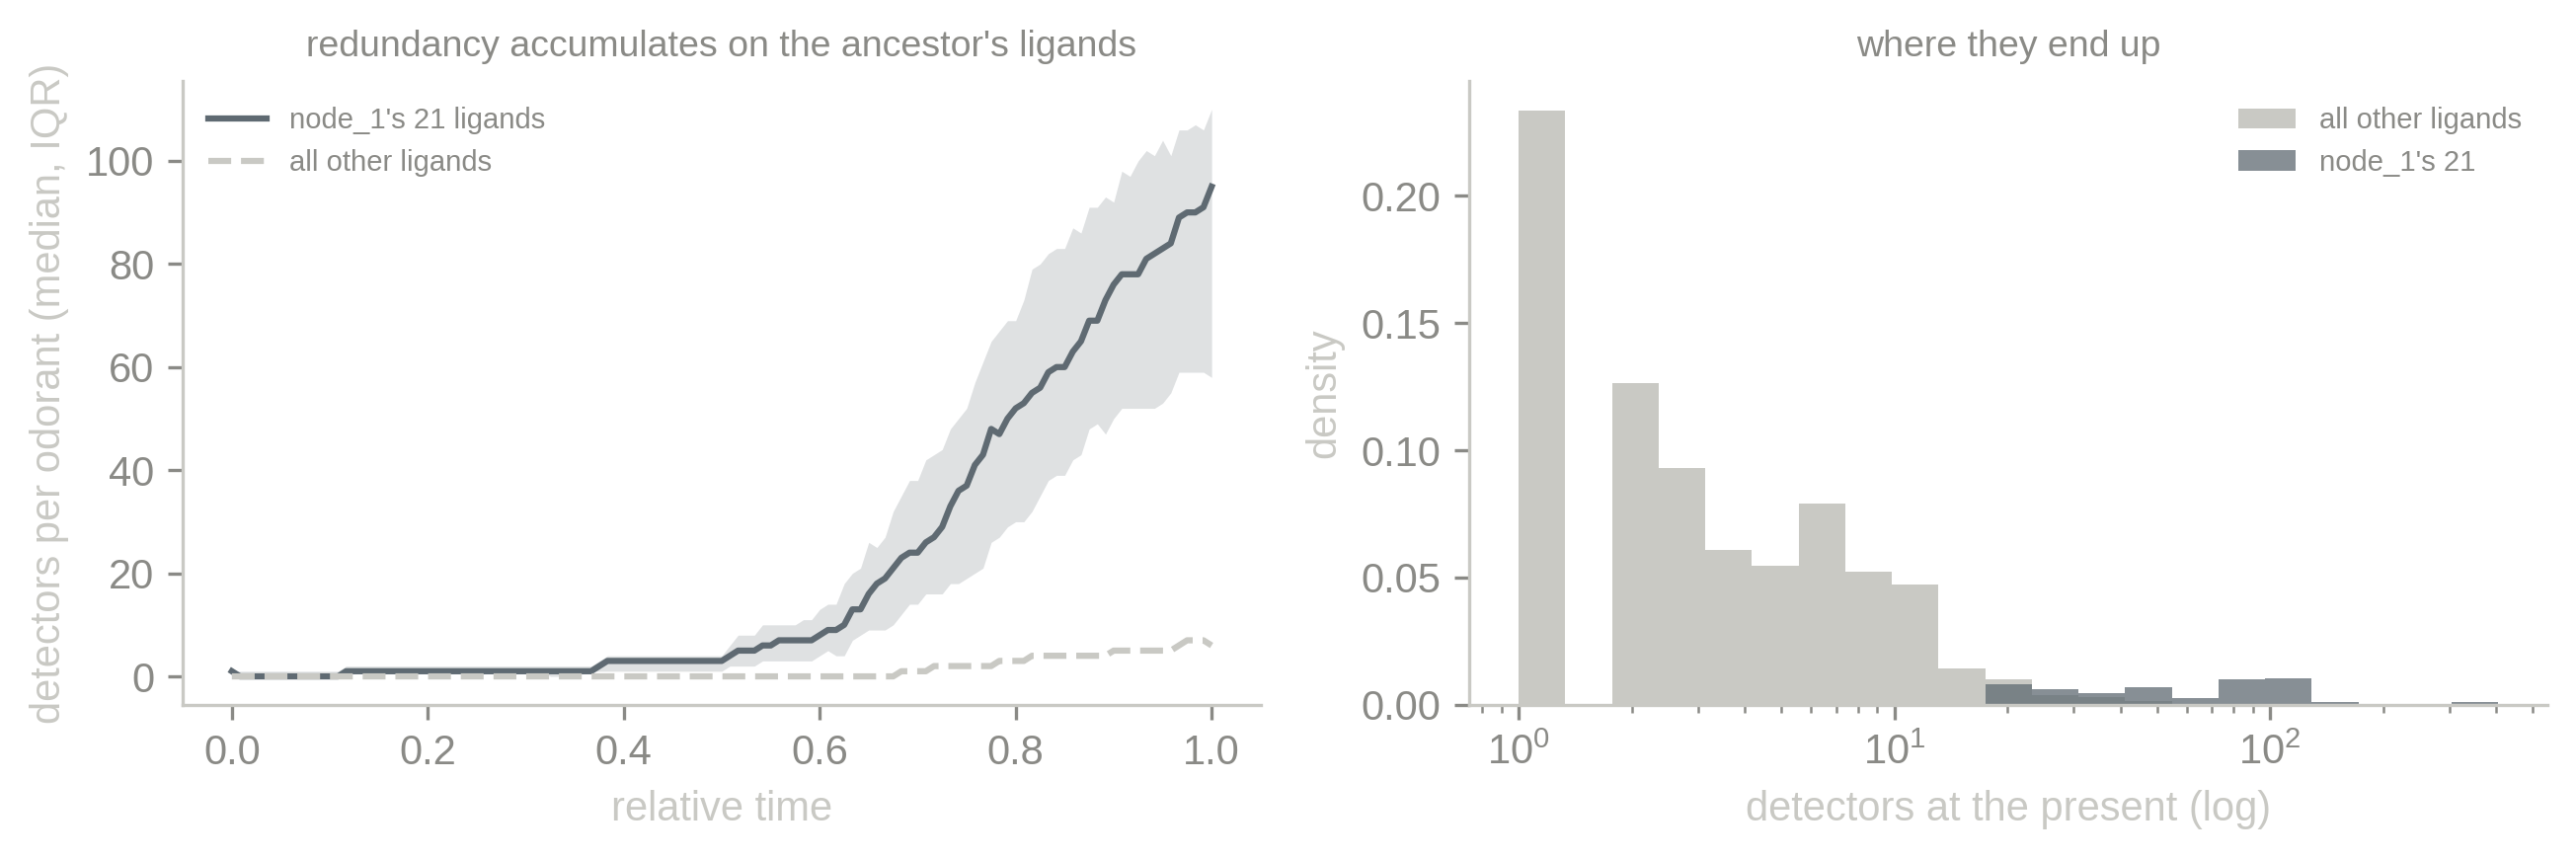

median detectors at the present: founders 95, others 6
founder ligands still detected at the present: 21 of 21


In [8]:
founders = list(binary.columns[binary.loc["node_1"].values])
others = [c for c in binary.columns if c not in founders]
print(f"node_1 binds {len(founders)} odorants")

grid = np.linspace(0, 1, 121)
keep = []
for when in grid:
    members = [m for m in lineage_slice(mpl, float(when)) if m in binary.index]
    block = binary.loc[members]
    det_f = block[founders].values.sum(0)
    det_o = block[others].values.sum(0)
    keep.append({"t": when, "n_lineages": len(members),
                 "founder_median": float(np.median(det_f)),
                 "founder_lo": float(np.percentile(det_f, 25)),
                 "founder_hi": float(np.percentile(det_f, 75)),
                 "other_median": float(np.median(det_o)),
                 "founder_still_detected": int((det_f > 0).sum())})
founder_traj = pd.DataFrame(keep)
save_table(founder_traj, "06_founder_ligands")

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1]))

ax = axes[0]
ax.fill_between(founder_traj.t, founder_traj.founder_lo, founder_traj.founder_hi,
                color=COMMON_COL, alpha=0.20, lw=0)
ax.plot(founder_traj.t, founder_traj.founder_median, color=COMMON_COL, lw=1.5,
        label="node_1's 21 ligands")
ax.plot(founder_traj.t, founder_traj.other_median, color=NULL_COL, lw=1.5, ls="--",
        label="all other ligands")
ax.set_xlabel("relative time"); ax.set_ylabel("detectors per odorant (median, IQR)")
ax.legend(frameon=False, fontsize=7, loc="upper left")
ax.set_title("redundancy accumulates on the ancestor's ligands", fontsize=9)

ax = axes[1]
det_f = binary.loc[extant_I + extant_II, founders].values.sum(0)
det_o = binary.loc[extant_I + extant_II, others].values.sum(0)
edges = np.logspace(0, np.log10(max(det_f.max(), det_o.max()) + 1), 22)
ax.hist(det_o, bins=edges, color=NULL_COL, label="all other ligands", density=True)
ax.hist(det_f, bins=edges, color=COMMON_COL, alpha=0.75, label="node_1's 21", density=True)
ax.set_xscale("log"); ax.set_xlabel("detectors at the present (log)")
ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=7)
ax.set_title("where they end up", fontsize=9)

plt.tight_layout(); save_fig(fig, "06_founder_ligands"); plt.show()

print(f"median detectors at the present: founders {int(np.median(det_f))}, "
      f"others {int(np.median(det_o))}")
print(f"founder ligands still detected at the present: "
      f"{int(founder_traj.founder_still_detected.iloc[-1])} of {len(founders)}")

The ancestor's 21 ligands end up among the most redundantly encoded odorants in the
repertoire — a median of 95 detectors against 7 for everything else — and not one is
lost. The code does not move off its ancestral ligands; it piles receptors onto them
while adding new ones around them.

**This needs a caveat in any legend, because it is partly circular.** `node_1`'s
repertoire is the top of its own predicted score row, and if the model scores
intrinsically promiscuous odorants highly for every sequence, the ancestor's ligands
would be the broadly-detected ones whatever the tree did. The defensible version is
conditional: *given* the reconstruction, ancestral ligands are the redundancy core.
Separating that from a model artefact needs the odorant-level score distribution as
a null — worth doing before this panel carries any weight, and not done here.

## Controls

Three nulls. The first two are the memo's, the third tightens one of them.

**Ordering (§4.1)** — the reason the axis is time. Resolve the same topology in 200
random orders and read "Class I only" at twenty receptors.

**Composition (§4.3)** — the memo's most important caveat. Draw receptors at random
from the extant matrix in the class ratio the slice actually has at each *t*, with
no tree at all. If that reproduces the curve, the shape is the class ratio shifting
and not history.

**Independence (§4.4)** — combinatoriality is arithmetically forced at this density.
With receptors independent at their observed breadths, what fraction of detected
odorants would have two or more detectors anyway?

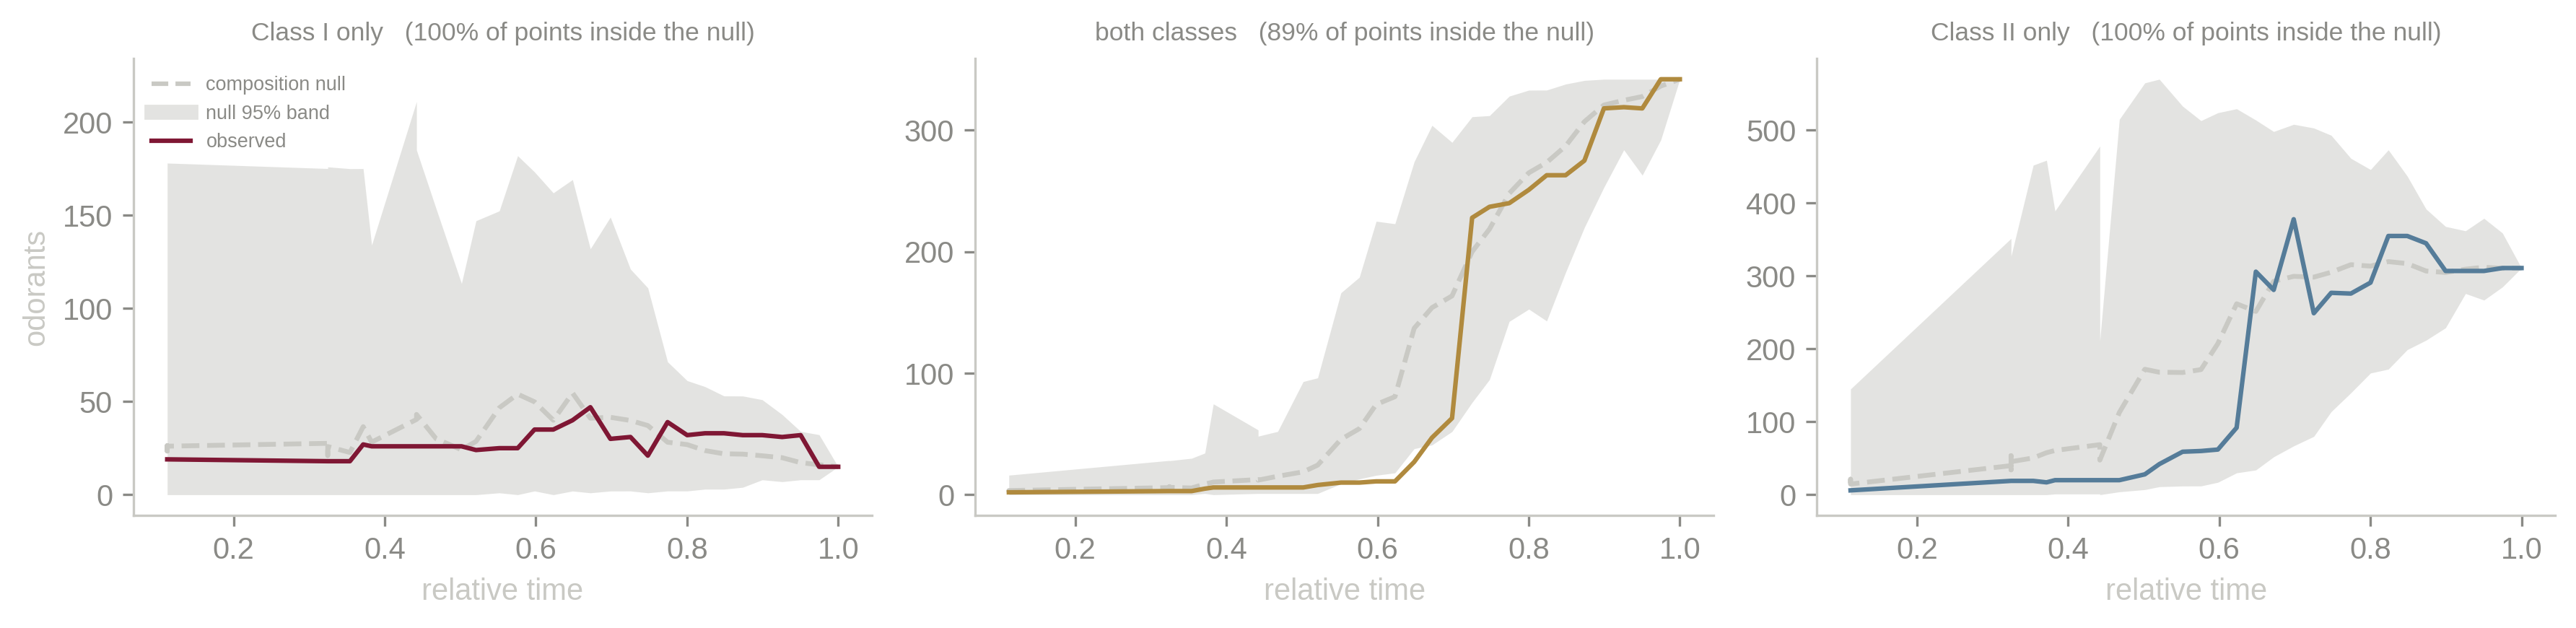

only_I    observed inside the null's 95% band at 100% of time points
both      observed inside the null's 95% band at 89% of time points
only_II   observed inside the null's 95% band at 100% of time points


In [9]:
MI_all, MII_all = binary.loc[extant_I].values, binary.loc[extant_II].values

# --- composition null, matched to the slice's class ratio at each t ---
coarse = np.linspace(0.02, 1.0, 40)
N_DRAW = 200
comp = []
for when in coarse:
    row = traj.iloc[(traj.t - when).abs().argmin()]
    kI, kII = int(row.n_class_I), int(row.n_class_II)
    if kI == 0 and kII == 0:
        continue
    oi, bo, oii = [], [], []
    for _ in range(N_DRAW):
        a = MI_all[RNG.choice(len(MI_all), min(kI, len(MI_all)), replace=False)].sum(0) > 0 \
            if kI else np.zeros(MI_all.shape[1], bool)
        b = MII_all[RNG.choice(len(MII_all), min(kII, len(MII_all)), replace=False)].sum(0) > 0 \
            if kII else np.zeros(MII_all.shape[1], bool)
        oi.append((a & ~b).sum()); bo.append((a & b).sum()); oii.append((~a & b).sum())
    entry = {"t": float(row.t), "n_I": kI, "n_II": kII,
             "only_I_obs": float(row.only_I), "both_obs": float(row.both),
             "only_II_obs": float(row.only_II)}
    for key, draws in [("only_I", oi), ("both", bo), ("only_II", oii)]:
        entry[f"{key}_null"] = np.mean(draws)
        entry[f"{key}_lo"] = np.percentile(draws, 2.5)
        entry[f"{key}_hi"] = np.percentile(draws, 97.5)
        entry[f"{key}_inside"] = bool(np.percentile(draws, 2.5) <= entry[f"{key}_obs"]
                                      <= np.percentile(draws, 97.5))
    comp.append(entry)
comp = pd.DataFrame(comp)
save_table(comp, "06_composition_null")

fig, axes = plt.subplots(1, 3, figsize=(FIGSIZE[0] * 3.0, FIGSIZE[1]))
for ax, key, col, name in [(axes[0], "only_I", CLASS1_COL, "Class I only"),
                           (axes[1], "both", BOTH_COL, "both classes"),
                           (axes[2], "only_II", CLASS2_COL, "Class II only")]:
    ax.fill_between(comp.t, comp[f"{key}_lo"], comp[f"{key}_hi"],
                    color=NULL_COL, alpha=0.5, lw=0)
    ax.plot(comp.t, comp[f"{key}_null"], color=NULL_COL, lw=1.6, ls="--")
    ax.plot(comp.t, comp[f"{key}_obs"], color=col, lw=1.5)
    inside = comp[f"{key}_inside"].mean()
    ax.set_xlabel("relative time")
    ax.set_title(f"{name}   ({inside:.0%} of points inside the null)", fontsize=8.5)
axes[0].set_ylabel("odorants")
axes[0].legend(handles=[Line2D([], [], color=NULL_COL, ls="--", label="composition null"),
                        Line2D([], [], color=NULL_COL, lw=5, alpha=0.5, label="null 95% band"),
                        Line2D([], [], color=CLASS1_COL, label="observed")],
               frameon=False, fontsize=6.5, loc="upper left")
plt.tight_layout(); save_fig(fig, "06_composition_null"); plt.show()

for key in ["only_I", "both", "only_II"]:
    print(f"{key:9s} observed inside the null's 95% band at "
          f"{comp[f'{key}_inside'].mean():.0%} of time points")

'Class I only' at ~20 lineages across 200 random resolution orders: [13, 267]  median 59
the tree's own slice nearest 20 lineages (t=0.527): only_I = 24, Class I share of receptors = 0.10
same on the raw axis (t=0.373): Class I share = 0.65


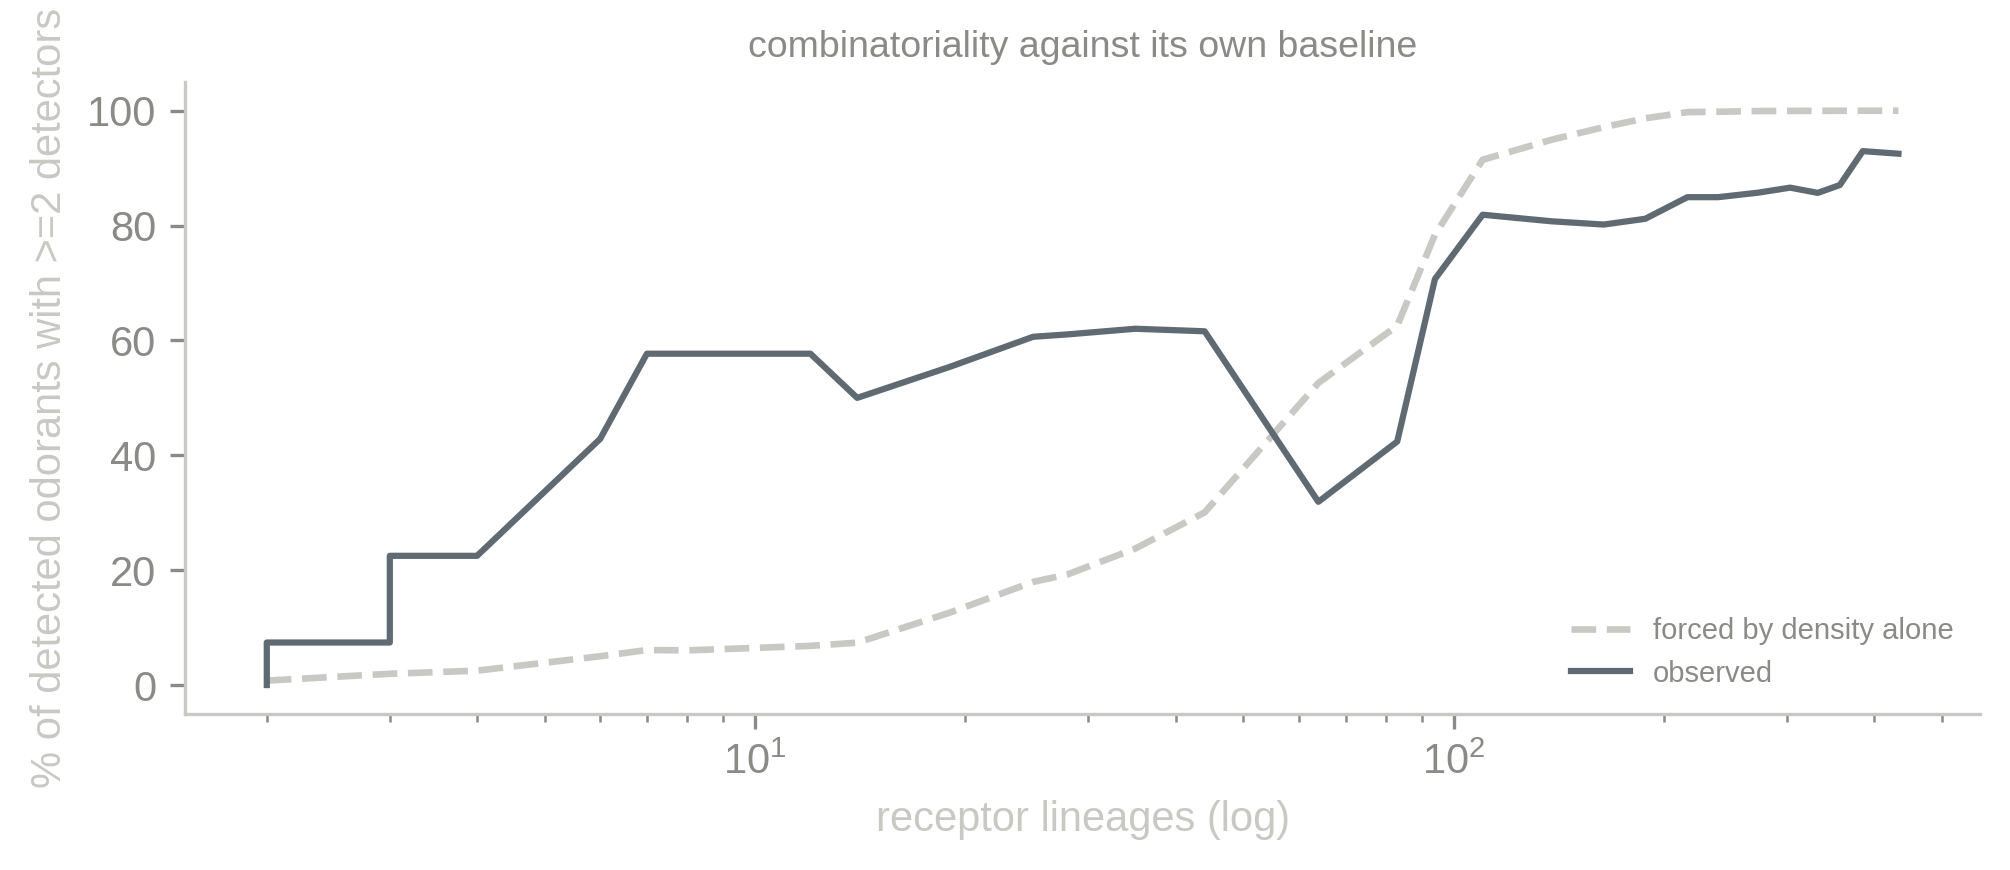

observed exceeds the forced baseline up to 44 lineages, and stays below it thereafter
  at  94 lineages: forced 78.4%, observed 70.7%
  at 433 lineages: forced 100.0%, observed 92.5%


In [10]:
# --- ordering null (memo 4.1): random resolution orders on the SAME topology ---
# Start from node_1 and repeatedly expand a randomly chosen unresolved lineage.
# Every order is consistent with the tree; only the sequence of splits varies.
K = 20
spans = []
for _ in range(200):
    live = ["node_1"]
    while len(live) < K:
        internal = [i for i, m in enumerate(live) if not index[m].is_leaf]
        if not internal:
            break
        pick = live.pop(int(RNG.choice(internal)))
        live.extend(c.name for c in index[pick].children)
    members = [m for m in live if m in binary.index]
    in_i = [m for m in members if m in clades["Class_I"]]
    in_ii = [m for m in members if m in clades["Class_II"]]
    av = binary.loc[in_i].values.sum(0) > 0 if in_i else np.zeros(binary.shape[1], bool)
    bv = binary.loc[in_ii].values.sum(0) > 0 if in_ii else np.zeros(binary.shape[1], bool)
    spans.append(int((av & ~bv).sum()))
print(f"'Class I only' at ~{K} lineages across 200 random resolution orders: "
      f"[{min(spans)}, {max(spans)}]  median {int(np.median(spans))}")

row20 = traj.iloc[(traj.n_lineages - K).abs().argmin()]
print(f"the tree's own slice nearest {K} lineages (t={row20.t:.3f}): "
      f"only_I = {int(row20.only_I)}, Class I share of receptors = "
      f"{row20.n_class_I / max(row20.n_lineages, 1):.2f}")
raw20 = traj_raw.iloc[(traj_raw.n_lineages - K).abs().argmin()]
print(f"same on the raw axis (t={raw20.t:.3f}): Class I share = "
      f"{raw20.n_class_I / max(raw20.n_lineages, 1):.2f}")

# --- independence null (memo 4.4) ---
def forced_combinatorial(rows):
    p = binary.loc[rows].values.mean(axis=1)          # each receptor's breadth as a rate
    none = np.prod(1 - p)
    exactly_one = sum(pi / (1 - pi) for pi in p if pi < 1) * none
    detected = 1 - none
    return (detected - exactly_one) / detected if detected > 0 else np.nan

ind = []
for when in coarse:
    members = [m for m in lineage_slice(mpl, float(when)) if m in binary.index]
    row = traj.iloc[(traj.t - when).abs().argmin()]
    obs = row.n_combinatorial / row.n_detected if row.n_detected else np.nan
    ind.append({"t": float(row.t), "n": len(members),
                "observed": obs, "forced": forced_combinatorial(members)})
ind = pd.DataFrame(ind)
save_table(ind, "06_independence_null")

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.7, FIGSIZE[1]))
ax.plot(ind.n, ind.forced * 100, color=NULL_COL, lw=1.6, ls="--", label="forced by density alone")
ax.plot(ind.n, ind.observed * 100, color=COMMON_COL, lw=1.5, label="observed")
ax.set_xscale("log"); ax.set_xlabel("receptor lineages (log)")
ax.set_ylabel("% of detected odorants with >=2 detectors")
ax.legend(frameon=False, fontsize=7, loc="lower right")
ax.set_title("combinatoriality against its own baseline", fontsize=9)
plt.tight_layout(); save_fig(fig, "06_independence_null"); plt.show()

above = ind[(ind.observed >= ind.forced) & (ind.n > 3)]
if len(above):
    print(f"observed exceeds the forced baseline up to {int(above.n.max())} lineages, "
          f"and stays below it thereafter")
for target in [100, 433]:
    r = ind.iloc[(ind.n - target).abs().argmin()]
    print(f"  at {int(r.n):>3} lineages: forced {r.forced:.1%}, observed {r.observed:.1%}")

The ordering null lands where the memo says it does. "Class I only" at twenty
lineages spans [13, 267] across 200 resolution orders of the *same tree* — a range
covering almost the entire achievable scale — against 24 for the tree's own slice at
that size. Repertoire size is not an axis; it is a free parameter dressed as one.

The composition null does not merely bite — it removes the claim. The observed
curves sit inside the null's 95% band at nearly every time point in all three
panels. Drawing receptors at random from the extant matrix, in nothing but the class
ratio the slice happens to have, reproduces the whole shape: the thin "Class I only"
band, its rise and fall, and the late build-up of "both classes".

This is worth stating more sharply than the memo does. Its §3 conclusion — that the
shared ligand pool "is not an inherited ancestral condition but something the Class
II radiation builds over a Class I repertoire already in place" — is true as a
description of the curve, but the curve is what you get from *any* 62-and-371 mix of
these receptors, tree or no tree. "Built late" is a restatement of the fact that most
receptors arrive late. **Any evolutionary sentence about these panels has to be a
sentence about the residual between the coloured line and the dashed one, and here
that residual is not distinguishable from zero.**

What does survive is the receptor-count panel, which is not a composition result:
the class ratio *itself* changing over time is the finding, and the odorant panels
are its consequence rather than independent evidence.

The independence panel makes the memo's §4.4 point visually: past roughly 50
receptors the real code is *less* combinatorial than independent receptors at the
same breadths would be. A rising %-combinatorial curve is therefore not evidence of
a code becoming combinatorial — it is arithmetic. What is interesting is the
opposite, that the real code stays under the forced baseline, which is a hint of
structure that resists it.

## Sensitivity

Two checks. First the hyper-broad rows the memo flags in §5: breadth is median 4
but reaches into the hundreds, and a couple of very broad reconstructions can
dominate the odorant counts wherever they sit in the sweep.

breadth, all 865 rows: median 6, max 572, 29 above 100
breadth, extant only:      median 4, max 572   (the memo quotes median 4, max 539)
9606.Q9Y3N9    572
9606.O76001    543
9606.P34982    458
9606.P47890    402
node_314       390


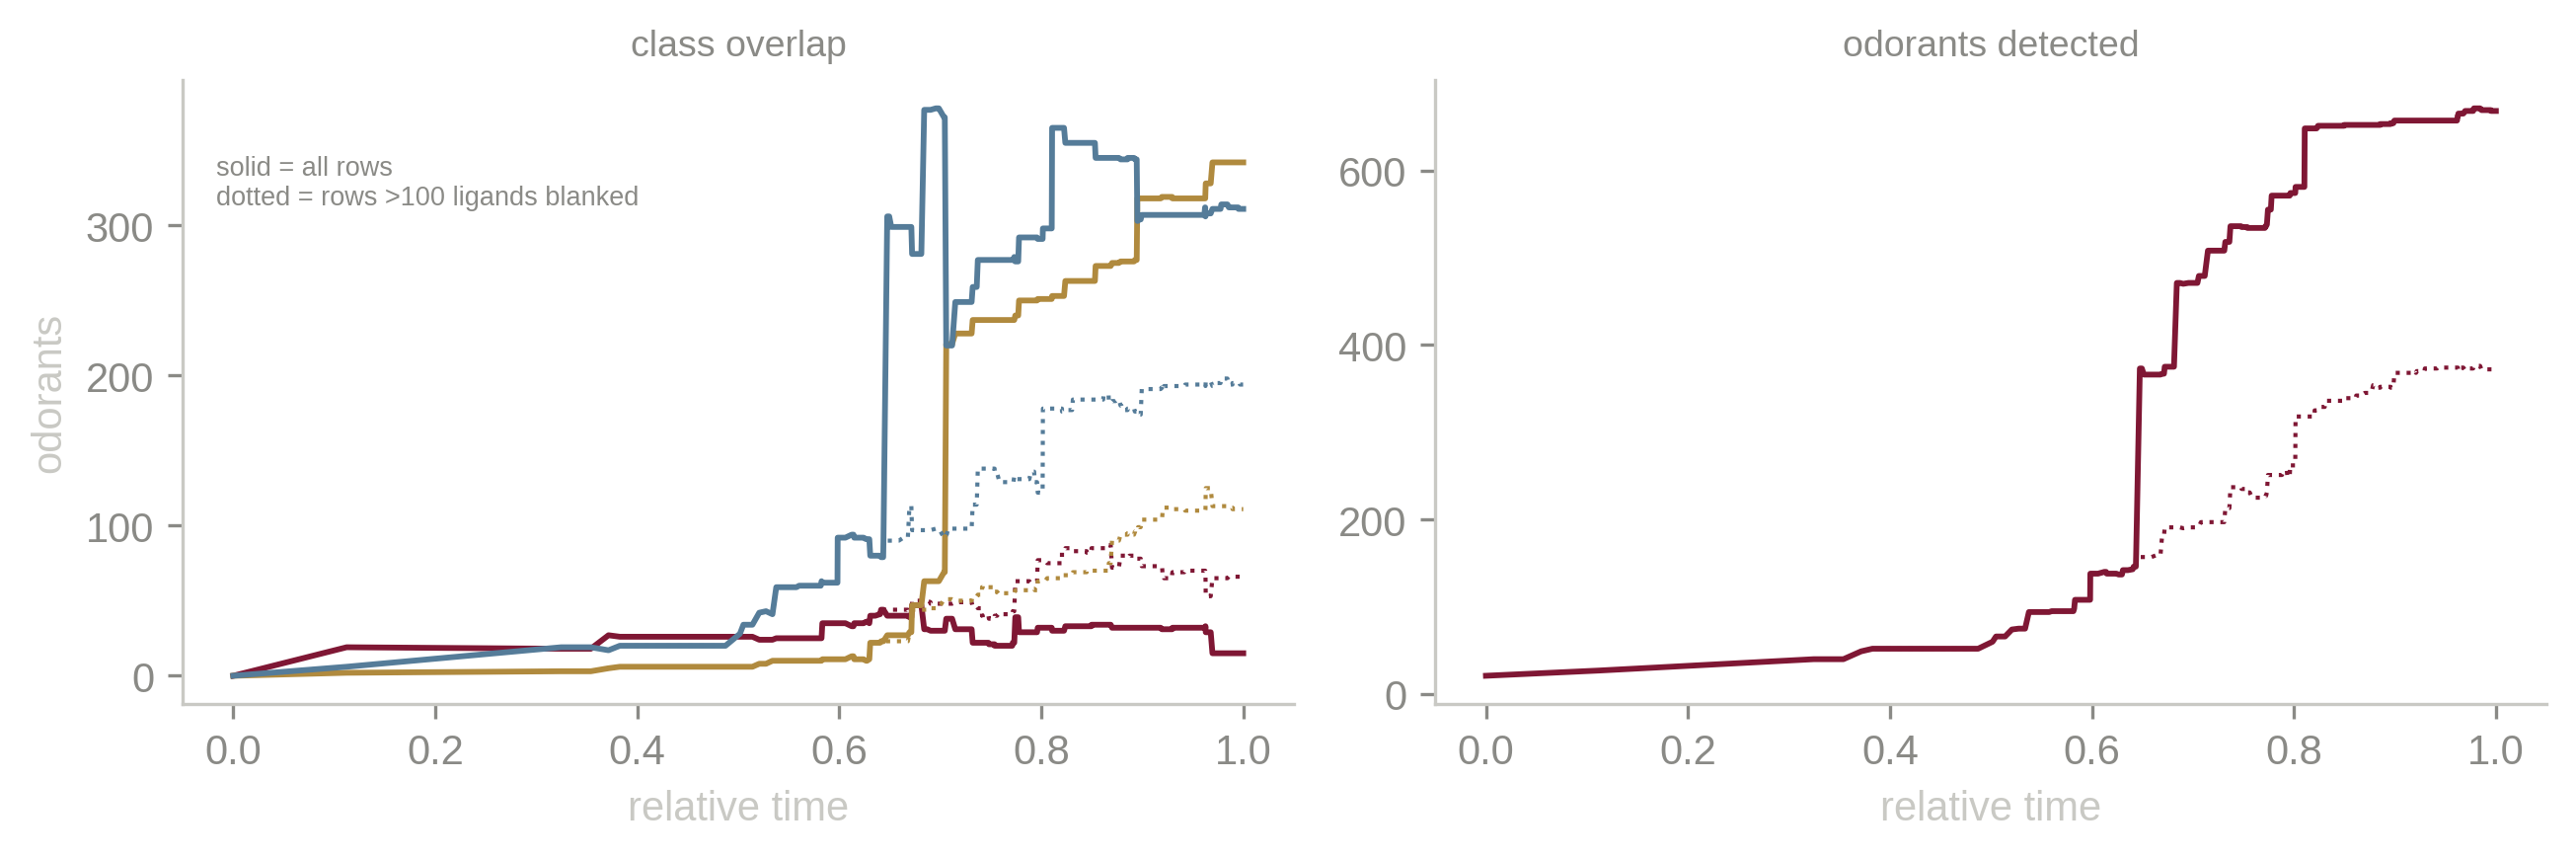

all rows       largest single step  216 odorants (t=0.647), endpoint 668
blanked >100   largest single step   56 odorants (t=0.802), endpoint 371


In [11]:
breadth = binary.sum(axis=1)
extant_breadth = breadth.loc[extant_I + extant_II]
print(f"breadth, all {len(breadth)} rows: median {int(breadth.median())}, "
      f"max {int(breadth.max())}, {int((breadth > 100).sum())} above 100")
print(f"breadth, extant only:      median {int(extant_breadth.median())}, "
      f"max {int(extant_breadth.max())}   (the memo quotes median 4, max 539)")
print(breadth.sort_values(ascending=False).head(5).to_string())

traj_blank = trajectory(mpl, blank_above=100)
save_table(traj_blank, "06_trajectory_blanked")

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1]))
for ax, cols, title in [(axes[0], ["only_I", "both", "only_II"], "class overlap"),
                        (axes[1], ["n_detected"], "odorants detected")]:
    for c, col in zip(cols, [CLASS1_COL, BOTH_COL, CLASS2_COL]):
        ax.plot(traj.t, traj[c], color=col, lw=1.4)
        ax.plot(traj_blank.t, traj_blank[c], color=col, lw=1.0, ls=":")
    ax.set_xlabel("relative time"); ax.set_title(title, fontsize=9)
axes[0].set_ylabel("odorants")
axes[0].annotate("solid = all rows\ndotted = rows >100 ligands blanked",
                 xy=(0.03, 0.80), xycoords="axes fraction", fontsize=6.5, color="#8a8a86")
plt.tight_layout(); save_fig(fig, "06_sensitivity_broad"); plt.show()

for nm, df in [("all rows", traj), ("blanked >100", traj_blank)]:
    d = df.n_detected.diff().abs()
    print(f"{nm:14s} largest single step {int(d.max()):>4} odorants "
          f"(t={df.t[d.idxmax()]:.3f}), endpoint {int(df.n_detected.iloc[-1])}")

Blanking is not a cosmetic sensitivity here. It removes 29 of 865 rows — 3% — and
takes 45% of the odorants with them (668 to 371), because a row calling 288 or 572
ligands contributes almost the whole ligand set on its own. The class-level shape
survives, which is the memo's claim and it holds; the absolute odorant counts do
not survive in any form, and should not be quoted without the blanked figure beside
them.

Whether those rows are real is a separate question this notebook cannot answer.
A reconstruction called at 572 of 754 ligands is either a genuinely promiscuous
receptor or a low-confidence ancestral sequence whose scores are flat enough that
the density fill takes the top 76% of its row. Distinguishing the two needs the ASR
posterior probabilities per site, which are available in the reconstruction output
and are not used anywhere in this folder. That is the most useful next step for this
analysis, more so than any additional panel.

### The endpoint disagreement

The memo's third acceptance test — "the final point reproduces 17 / 370 / 300
exactly" — does not reproduce here. This folder gets **15 / 342 / 311**, with 668
odorants detected rather than 687 and 50 singly-detected rather than 61.

The cause is not the tree, the class assignment or the matrix. It is the
**experimental overlay**. The memo's numbers come from an extant fill with the
23,782 measured human pairs overlaid on the predictions; this folder fills with no
overlay anywhere. Substituting the overlay reproduces the memo's numbers to the
digit — including its extant cut of 0.8917, which is the overlay cut, where the
no-overlay cut is 0.8947.

The next cell shows both.

In [12]:
from calibration import density_fill, reference_calibration_map
from ancestral_sets import ASR_MATRIX, REF_MATRIX, PAIRS, FASTA

asr_raw = pd.read_csv(ASR_MATRIX, index_col=0)
asr_raw.index = [str(i).replace("_ASR", "") for i in asr_raw.index]
ref_raw = pd.read_csv(REF_MATRIX, index_col=0)
ref_raw = ref_raw[[str(i).startswith("9606") for i in ref_raw.index]]
ligand_cols = [c for c in asr_raw.columns if c.startswith("SML") and c in ref_raw.columns]
ref_raw = ref_raw[ligand_cols]

seqs, pid, buf = {}, None, []
for line in open(FASTA):
    line = line.rstrip()
    if line.startswith(">"):
        if pid:
            seqs[pid] = "".join(buf).upper()
        pid, buf = line[1:].split()[0], []
    else:
        buf.append(line)
if pid:
    seqs[pid] = "".join(buf).upper()

seq_to_pid = {}
for p in ref_raw.index:
    seq_to_pid.setdefault(seqs[p], p)
pairs = pd.read_csv(PAIRS, usecols=["Species", "Sequence", "Responsive", "smiles_id"])
hp = pairs[pairs.Species.str.lower().str.contains("homo")].copy()
hp["Sequence"] = hp.Sequence.str.upper().str.strip()
hp["pid"] = hp.Sequence.map(seq_to_pid)
meas = (hp[hp.pid.notna() & hp.smiles_id.isin(ligand_cols)]
        .groupby(["pid", "smiles_id"]).Responsive.max())

ri = {p: i for i, p in enumerate(ref_raw.index)}
ci = {c: j for j, c in enumerate(ligand_cols)}
mask = np.zeros(ref_raw.shape, bool); exper = np.zeros(ref_raw.shape, float)
for (p, s), v in meas.items():
    mask[ri[p], ci[s]] = True; exper[ri[p], ci[s]] = v
print(f"{len(meas)} measured cells, {int(meas.sum())} positive")

iso = reference_calibration_map(REF_MATRIX, PAIRS, FASTA)
summary = []
for label, kw in [("no overlay (this folder)", dict(tested_mask=None)),
                  ("with overlay (the memo)", dict(tested_mask=mask, experimental=exper))]:
    r = density_fill(ref_raw.values, iso, **kw)
    B = pd.DataFrame(r.matrix.astype(bool), index=ref_raw.index, columns=ligand_cols)
    a = B.loc[extant_I].values.sum(0) > 0
    b = B.loc[extant_II].values.sum(0) > 0
    det = B.values.sum(0)
    summary.append({"fill": label, "cut": round(r.cut, 4), "density": f"{r.density:.4%}",
                    "only_I": int((a & ~b).sum()), "both": int((a & b).sum()),
                    "only_II": int((~a & b).sum()), "detected": int((det > 0).sum()),
                    "single": int((det == 1).sum()), "combinatorial": int((det >= 2).sum())})
summary = pd.DataFrame(summary)
save_table(summary, "06_endpoint_overlay")
print(summary.to_string(index=False))

23782 measured cells, 1128 positive
                    fill    cut density  only_I  both  only_II  detected  single  combinatorial
no overlay (this folder) 0.8947 2.7453%      15   342      311       668      50            618
 with overlay (the memo) 0.8917 2.7453%      17   370      300       687      61            626


Both fills are legitimate; they answer different questions. But only one of them is
usable *here*, and it is not the memo's.

An ancestor cannot have measurements. Overlaying them on the extant rows alone
therefore puts a systematic data-source discontinuity on every ancestor-to-tip edge
of the tree — and this trajectory crosses all 433 of those edges at once, at *t* = 1,
which is exactly where the headline number 17 / 370 / 300 is read. Part of the final
step in the memo's curves is not evolution over the terminal branches; it is
measurements switching on. The effect is not large — 19 odorants, 2.8% — but it
is systematic, it points one way, and 11 of those 19 land in the single-detector
category that §4.4 already identifies as the softest in the analysis.

So: **the memo's acceptance test cannot be satisfied without adopting a binarisation
that is internally inconsistent with the analysis it is testing.** The
recommendation is to keep the no-overlay fill throughout, report 15 / 342 / 311 as
the endpoint, and cite the overlay figures as the sensitivity — the direction this
notebook takes.

That also disposes of the memo's §6 triage. Of its three checks, (2) is the one that
would catch a wrong MPL implementation and it passes cleanly; (1) is not
reproducible as stated because its tolerance is unstated; and (3) cannot pass
without changing the binarisation. Check (2) should be the gate.

## Summary

What survives, in descending order of how much weight it will carry:

1. **The duplication asymmetry is real and is the safest claim here.** Class I
   flattens near 62 lineages while Class II keeps expanding, on both the ultrametric
   and the raw axis. It does not depend on the clock assumption, the threshold, or
   the overlay.
2. **The class-overlap panel does not carry independent evidence.** "Both classes"
   grows late and "Class I only" stays thin, but the composition null reproduces
   both inside its 95% band at nearly every time point. The odorant panels are a
   consequence of the changing class ratio, not a second finding about it. This is
   a stronger negative than the memo states, and it should change how the panel is
   captioned.
3. **Timing is bracketed, not measured.** Class I's share at twenty receptors moves
   substantially between the two axes. Report the shape.
4. **The rise in combinatoriality is arithmetic.** Past ~50 receptors the real code
   is less combinatorial than chance at the same density. Plot the detector-count
   distribution, not the binary split.
5. **The curve is an estimator with variance.** Standing repertoire is non-monotone
   and intermediate counts jitter by tens; endpoints are solid, the middle is not.
6. **Absolute odorant counts are carried by 29 hyper-broad rows.** Blanking 3% of
   rows removes 45% of the odorants and flattens the largest step from 216 to 56.
   Quote class-level shape; do not quote odorant totals without the blanked figure.

Two things this notebook changes about how the analysis should be reported. The
endpoint should be 15 / 342 / 311, not 17 / 370 / 300, because the latter needs an
extant-only experimental overlay that the trajectory itself cannot support. And the
memo's acceptance test (3) should be retired in favour of test (2), which is the one
that actually validates the axis.

The single most useful next step is not another panel: it is bringing the ASR
per-site posterior probabilities into the binarisation, so that a reconstruction
called at 288 ligands can be distinguished from a confident one called at 6.

The memo's own §5 closing point stands and is worth repeating in any legend: the
version of this analysis that would actually narrow the timing bracket needs
taxonomic gain/loss mapping across many vertebrate genomes, not a human-only tree.
This notebook is the human-only version, with its limits drawn rather than described.